1. **Problem to demonstrate that the population regression line is fixed, but least square regression line varies**

Suppose the population regression line is given by $Y = 2 + 3x$, while the data
comes from the model $y = 2 + 3x + ϵ$. <br>
Step 1: For $x$ in the range [5,10] graph the population regression line.<br>
Step 2: Generate $x_i$(i = 1, 2, .., n) from $Uniform(5, 10)$ and $ϵ_i$(i = 1, 2, .., n)
from $N(0, 4^2)$. Hence, compute $y_1, y_2, .., y_n$.<br>
Step 3: On the basis of the data $(x_i, y_i)$(i = 1, 2, .., n) generated in Step 2,
report the least squares regression line.<br>
Step 4: Repeat steps 2-3 five times. Graph the 5 least squares regression lines
over the population regression line obtained in Step 1.<br>
Interpret the findings.
Take n = 50. Set the seed as seed=123.

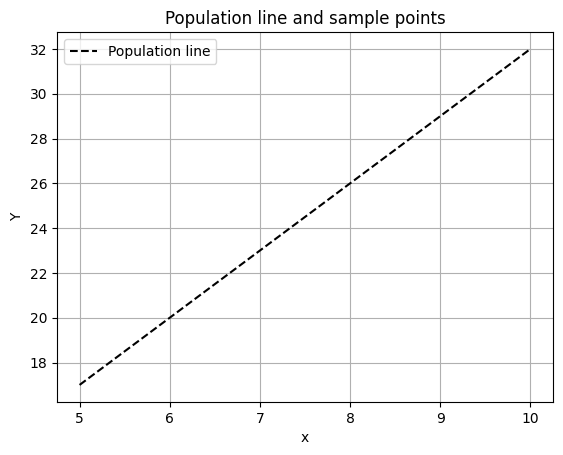

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(123)
n = 50
x = np.linspace(5, 10, n)
Y = 2 + 3*x
plt.plot(x, Y, 'k--', label = 'Population line')
plt.xlabel('x')
plt.ylabel('Y')
plt.title('Population line and sample points')
plt.grid(True)
plt.legend()
plt.show()

In [2]:
X = np.random.uniform(5, 10, n)
e = np.random.normal(0, 4, n)
y = 2 + 3*X + e
print(y)

[31.36198181 30.24466338 15.22643051 21.1145687  34.76688345 20.15434596
 31.8301959  31.54970996 27.77680409 29.9013075  28.13024679 32.21331629
 20.48774881 21.07461912 24.22775181 22.76486925 25.40657214 22.86072248
 25.15523093 24.04504556 21.7228098  30.53957321 29.74058635 22.84073272
 32.48546693 17.45557152 13.93442843 24.58285683 19.79224654 25.96052352
 15.03150721 17.08166655 28.48389095 21.64980053 30.03126431 24.91315109
 22.13623702 26.05722784 28.23255233 19.67745761 34.70774772 19.39204085
 26.3601044  18.15298498 30.71877789 25.46827824 22.90547092 35.90785462
 20.45400514 20.73953171]


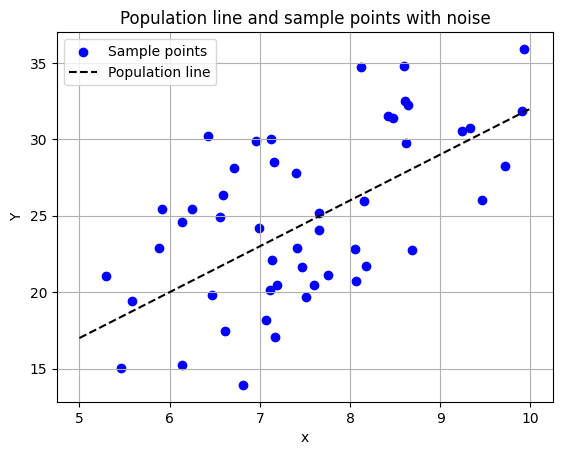

In [3]:
plt.scatter(X, y, color = 'blue', label = 'Sample points')
plt.plot(x, Y, 'k--', label = 'Population line')
plt.xlabel('x')
plt.ylabel('Y')
plt.title('Population line and sample points with noise')
plt.grid(True)
plt.legend()
plt.show()

In [4]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [5]:
reg = model.fit(X.reshape(-1, 1), y)
print('Estimated intercept:', reg.intercept_)
print('Estimated slope:', reg.coef_[0])

Estimated intercept: 4.4127968569011
Estimated slope: 2.7347714902181375


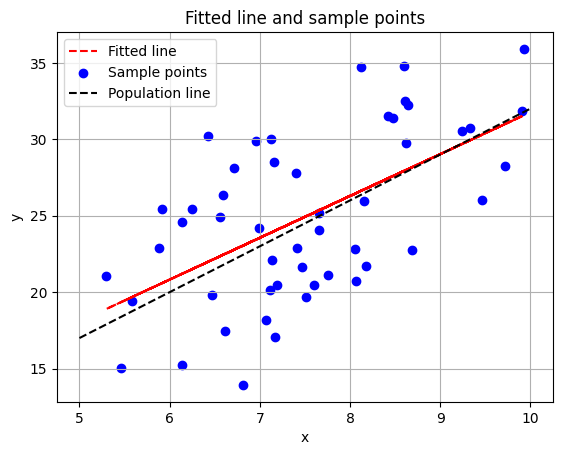

In [6]:
plt.plot(X, reg.intercept_ + reg.coef_[0]*X, 'r--', label = 'Fitted line')
plt.scatter(X, y, color = 'blue', label = 'Sample points')
plt.plot(x, Y, 'k--', label = 'Population line')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Fitted line and sample points')
plt.grid(True)
plt.legend()
plt.show()

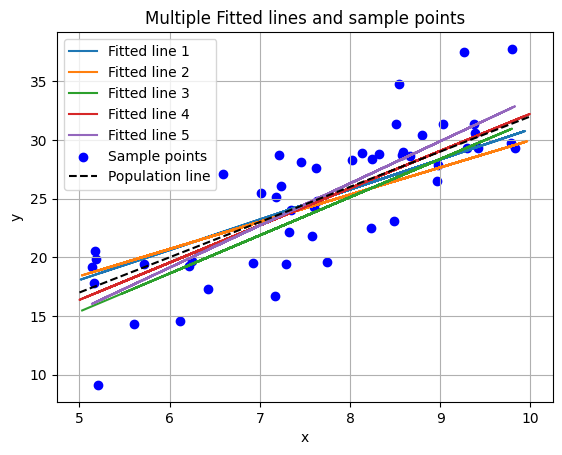

In [7]:
for i in range(5):
    n = 50
    x = np.linspace(5, 10, n)
    Y = 2 + 3*x
    X = np.random.uniform(5, 10, n)
    e = np.random.normal(0, 4, n)
    y = 2 + 3*X + e
    model = LinearRegression()
    reg = model.fit(X.reshape(-1, 1), y)
    plt.plot(X, reg.intercept_ + reg.coef_[0]*X, label = f'Fitted line {i+1}')
plt.scatter(X, y, color = 'blue', label = 'Sample points')
plt.plot(x, Y, 'k--', label = 'Population line')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Multiple Fitted lines and sample points')
plt.grid(True)
plt.legend()
plt.show()

Based on the results, we can say that while the population relationship is constant, the estimated lines vary from sample to sample due to the random error term ($\epsilon$). However, these estimated lines fluctuate around the true population line, indicating that while individual sample estimates vary, they aim to approximate the true fixed parameter.

---

2. **Problem to demonstrate that $\hat{β_0}$ and $\hat{β}$ minimises RSS**
Step 1: Generate $x_i$ from $Uniform(5, 10)$ and mean centre the values. Generate $ϵ_i$ from $N(0, 1)$. Calculate $y_i = 2 + 3x_i + ϵ_i$, i = 1,2,.., n. Take n=50 and seed=123.<br>
Step 2: Now imagine that you only have the data on $(x_i, y_i)$, i = 1, 2, .., n, without knowing the mechanism that was used to generate the data in step 1.<br>
Assuming a linear regression of the type $y_i = β_0 +βx_i +ϵ_i$, and based on these data $(xi, yi)$, i = 1, 2, .., n, obtain the least squares estimates of β0 and β.<br>
Step 3: Take a large number of grid values of $(β_0, β)$ that also include the least squares estimates obtained from step 2. Compute the RSS for each parametric choice of $(β_0, β)$, where $RSS = (y_1 − β_0 − βx_1)^2 + (y_2 − β_0 − βx_2)^2 + ....(y_n −β_0 − βx_n)^2$. Find out for which combination of $(β_0, β)$, RSS is minimum.

In [8]:
np.random.seed(123)
n = 50
x = np.random.uniform(5, 10, n)
e = np.random.normal(0, 1, n)
y = 2 + 3*x + e
y_bar = np.mean(y)
cov = np.cov(x, y, bias=True)[0][1]
beta_1_hat = cov / np.var(x)
beta_0_hat = y_bar - beta_1_hat * np.mean(x)
print('Estimated intercept:', beta_0_hat)
print('Estimated slope:', beta_1_hat)

Estimated intercept: 2.6031992142252776
Estimated slope: 2.933692872554534


In [9]:
RSS_grid = np.zeros((1000, 1000))
beta_1_grid = np.linspace(2.5, 3.5, 1000)
beta_0_grid = np.linspace(1.75, 2.75, 1000)
for i in range(1000):
    beta_1 = beta_1_grid[i]
    for j in range(1000):
        beta_0 = beta_0_grid[j]
        RSS_grid[i, j] = np.sum((y - (beta_0 + beta_1 * x))**2)
print('Minimum RSS:', RSS_grid.min())
beta_1_hat_idx, beta_0_hat_idx = np.unravel_index(np.argmin(RSS_grid), RSS_grid.shape)
print('Estimated intercept from grid search corresponding to minimum RSS:', beta_0_grid[beta_0_hat_idx])
print('Estimated slope from grid search corresponding to minimum RSS:', beta_1_grid[beta_1_hat_idx])

Minimum RSS: 61.425507086957296
Estimated intercept from grid search corresponding to minimum RSS: 2.604854854854855
Estimated slope from grid search corresponding to minimum RSS: 2.9334334334334335


 3. **Problem to demonstrate that least square estimators are unbiased**

Step 1: Generate $x_i$(i = 1, 2, .., n) from $Uniform(0, 1)$, $ϵ_i$(i = 1, 2, .., n) from $N(0, 1)$ and hence generate y using $y_i = β_0 + βx_i + ϵ_i$. (Take $β_0$ = 2, $β$ = 3).<br>
Step 2: On the basis of the data $(x_i, y_i)$(i = 1, 2, .., n) generated in Step 1, obtain the least square estimates of $β_0$ and $β$.<br>
Repeat Steps 1-2, R = 1000 times. In each simulation obtain $\hat{β_0}$ and $\hat{β}$. Finally,the least-square estimates will be given by the average of these estimated values.<br>
Compare these with the true $β_0$ and $β$ and comment.
Take n = 50 and seed=123.


In [16]:
x = np.random.uniform(5, 10, n)
e = np.random.normal(0, 4, n)
y = 2 + 3*x + e
model2 = LinearRegression()
reg = model2.fit(x.reshape(-1, 1), y)
print('Estimated intercept with higher noise:', reg.intercept_)
print('Estimated slope with higher noise:', reg.coef_[0])



Estimated intercept with higher noise: 2.757356806484335
Estimated slope with higher noise: 3.007901736150082


In [17]:
beta_0_hat = np.zeros(1000)
beta_hat = np.zeros(1000)
for i in range(1000):
    n = 50
    x = np.random.uniform(5, 10, n)
    e = np.random.normal(0, 4, n)
    y = 2 + 3*x + e
    model2 = LinearRegression()
    reg = model2.fit(x.reshape(-1, 1), y)
    beta_0_hat[i] = reg.intercept_
    beta_hat[i] = reg.coef_[0]
beta_0_mean = np.mean(beta_0_hat)
beta_mean = np.mean(beta_hat)
print('Mean of estimated intercepts over 1000 simulations:', beta_0_mean)
print('Mean of estimated slopes over 1000 simulations:', beta_mean)


Mean of estimated intercepts over 1000 simulations: 2.1563247774246213
Mean of estimated slopes over 1000 simulations: 2.978536676381477


In the light of our calculations, we can say that the average of the estimated coefficients over a large number of simulations (1000) is very close to the true population parameters.The mean slope ($2.98$) is extremely close to the true slope ($3$).The mean intercept ($2.16$) is close to the true intercept ($2$).

---

 4. **Comparing several simple linear regressions**
Attach “Boston” data from MASS library in R. Select median value of owneroccupied homes, as the response and per capita crime rate, nitrogen oxides concentration, proportion of blacks and percentage of lower status of the population as predictors.
(a) Selecting the predictors one by one, run four separate linear regressions to the data. Present the output in a single table.<br>
(b) Which model gives the best fit?<br>
(c) Compare the coefficients of the predictors from each model and comment on the usefulness of the predictors.<br>







a)

In [19]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv')
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [26]:
slope = np.zeros(4)
intercept = np.zeros(4)
predictors = df[['crim', 'nox', 'b', 'lstat']]
response = df['medv']
model3 = LinearRegression()
for i in predictors.columns:
    model3.fit(predictors[[i]], response)
    slope[list(predictors.columns).index(i)] = model3.coef_[0]
    intercept[list(predictors.columns).index(i)] = model3.intercept_
estimated_table = pd.DataFrame({'Predictor': predictors.columns, 'Estimated Intercept': intercept, 'Estimated Slope': slope})
estimated_table

,Predictor,Estimated Intercept,Estimated Slope
0,crim,24.033106,-0.415190
1,nox,41.345874,-33.916055
2,b,10.551034,0.033593
3,lstat,34.553841,-0.950049


In [29]:
from sklearn.metrics import r2_score
r2_values = np.zeros(4)
for i in predictors.columns:
    model3.fit(predictors[[i]], response)
    y_pred = model3.predict(predictors[[i]])
    r2_values[list(predictors.columns).index(i)] = r2_score(response, y_pred)
r2_table = pd.DataFrame({'Predictor': predictors.columns, 'R-squared': r2_values})
r2_table

,Predictor,R-squared
0,crim,0.150780
1,nox,0.182603
2,b,0.111196
3,lstat,0.544146


b) In the light of our calculations, we can conclude that the model using `lstat` (percentage of lower status of the population) gives the best fit. The reason is that comparing the $R^2$ values in the output table, the lstat model has the highest value ($0.544$ or $54.4\%$), meaning it explains more than half of the variance in home prices. The other predictors explain significantly less variance (nox: $18.3\%$, crim: $15.1\%$, b: $11.1\%$).

c) The usefulness of the predictors are as follows:

* `lstat` (Slope: -0.95, $R^2$: 0.54): This is the most useful predictor. The negative slope indicates that as the percentage of lower-status population increases, median home values decrease significantly.

* `nox` (Slope: -33.92, $R^2$: 0.18): While the coefficient is very large in magnitude, this is due to the small scale of NOX concentration readings (0.4–0.8). It indicates a negative relationship (higher pollution = lower value), but it is a weak predictor compared to `lstat`.

* `crim` (Slope: -0.42, $R^2$: 0.15): A negative coefficient indicates that higher crime rates correlate with lower home values, but the low $R^2$ suggests crime rate alone is a poor predictor of price variance.

* `b` (Slope: 0.03, $R^2$: 0.11): The positive coefficient suggests a slight increase in value associated with this demographic metric, but it is the least useful predictor among the four, explaining only $\approx 11\%$ of the variance.